# Pre-check Launch Price

This notebook checks launch-price missingness and compaction feasibility in `BMT_launchprice.csv` before the full cleaning pipeline starts.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
SOURCE_PATH = NOTEBOOK_DIR / 'original_source' / 'BMT_launchprice.csv'

if not SOURCE_PATH.exists():
    raise FileNotFoundError(f'Expected source file at {SOURCE_PATH}')

plt.style.use('ggplot')


In [2]:
raw_df = pd.read_csv(SOURCE_PATH).copy()
raw_df['launch_price_krw'] = pd.to_numeric(raw_df['launch_price_krw'], errors='coerce')
raw_df['launch_price_missing'] = raw_df['launch_price_krw'].isna() | (raw_df['launch_price_krw'] <= 0)

compact_df = raw_df[
    ['brand', 'model_name', 'level_name', 'class_name', 'launch_price_krw', 'launch_price_missing']
].copy()

print(SOURCE_PATH)
print('raw shape:', raw_df.shape)
print('compact shape:', compact_df.shape)
compact_df.head()


/Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/data_collection/clean/original_source/BMT_launchprice.csv
raw shape: (7754, 10)
compact shape: (7754, 6)


,brand,model_name,level_name,class_name,launch_price_krw,launch_price_missing
0,chevrolet,뉴 볼트 EV,(전기),프리미어,41300000,False
1,chevrolet,더 넥스트 스파크,1.0,LS,10360000,False
2,chevrolet,더 넥스트 스파크,1.0,LS 베이직,9990000,False
3,chevrolet,더 넥스트 스파크,1.0,LS 베이직,9990000,False
4,chevrolet,더 넥스트 스파크,1.0,LT,11340000,False


## Level Name Dependency Check

Check whether `level_name` is functionally dependent on `brand + model_name + class_name`. If it is not, dropping `level_name` loses information.


In [3]:
level_dependency = (
    compact_df.groupby(['brand', 'model_name', 'class_name'], dropna=False)
    .agg(
        rows=('brand', 'size'),
        level_name_nunique=('level_name', 'nunique'),
        level_name_examples=('level_name', lambda s: sorted({str(v) for v in s.dropna()})[:5]),
    )
    .reset_index()
    .sort_values(['level_name_nunique', 'rows'], ascending=[False, False])
)

level_dependency.head(20)


,brand,model_name,class_name,rows,level_name_nunique,level_name_examples
1201,hyundai,파비스,-,31,31,"[고소작업차, 급수차, 내장탑차, 냉동탑차, 덤프]"
2085,kia,봉고3,-,29,29,"[1.2톤 냉동탑차, 1.2톤 냉장탑차, 1.4톤 내장탑차, 1.4톤 냉동탑차, 1..."
1229,hyundai,포터2,-,22,22,"[기타, 내장탑차, 냉동탑차, 냉장탑차, 다용도탑차]"
318,hyundai,e마이티,-,21,21,"[2.5톤 내장탑차, 2.5톤 냉동탑차, 2.5톤 덤프, 2.5톤 윙바디, 2톤 냉..."
1736,kia,뉴 그랜버드,47인승 자가용,15,15,"[그린필드(390마력), 그린필드(430마력), 그린필드(440마력), 블루스카이(..."
796,hyundai,스타리아,모던,17,14,"[1.6 하이브리드 카고 3인승 2WD, 1.6 하이브리드 카고 5인승 2WD, 1..."
571,hyundai,더 뉴 스타리아,모던,13,13,"[2.2 디젤 카고 3인승 2WD, 2.2 디젤 카고 5인승 2WD, 2.2 디젤 ..."
572,hyundai,더 뉴 스타리아,스마트,13,13,"[2.2 디젤 카고 3인승 2WD, 2.2 디젤 카고 5인승 2WD, 2.2 디젤 ..."
2010,kia,더 뉴 카니발 4세대,시그니처,13,13,"[1.6 터보 HEV 4인승 하이리무진, 1.6 터보 HEV 7인승, 1.6 터보 ..."
797,hyundai,스타리아,스마트,14,12,"[1.6 하이브리드 카고 3인승 2WD, 1.6 하이브리드 카고 5인승 2WD, 1..."


In [4]:
level_dependency_summary = pd.DataFrame([
    {
        'identifier': 'brand + model_name + class_name',
        'groups': len(level_dependency),
        'fd_holds_groups': int((level_dependency['level_name_nunique'] <= 1).sum()),
        'fd_breaks_groups': int((level_dependency['level_name_nunique'] > 1).sum()),
        'fd_break_ratio': float((level_dependency['level_name_nunique'] > 1).mean()),
    }
])

level_dependency_summary


,identifier,groups,fd_holds_groups,fd_breaks_groups,fd_break_ratio
0,brand + model_name + class_name,2636,1289,1347,0.511002


In [5]:
level_dependency.loc[
    level_dependency['level_name_nunique'] > 1,
    ['brand', 'model_name', 'class_name', 'rows', 'level_name_nunique', 'level_name_examples']
].head(30)


,brand,model_name,class_name,rows,level_name_nunique,level_name_examples
1201,hyundai,파비스,-,31,31,"[고소작업차, 급수차, 내장탑차, 냉동탑차, 덤프]"
2085,kia,봉고3,-,29,29,"[1.2톤 냉동탑차, 1.2톤 냉장탑차, 1.4톤 내장탑차, 1.4톤 냉동탑차, 1..."
1229,hyundai,포터2,-,22,22,"[기타, 내장탑차, 냉동탑차, 냉장탑차, 다용도탑차]"
318,hyundai,e마이티,-,21,21,"[2.5톤 내장탑차, 2.5톤 냉동탑차, 2.5톤 덤프, 2.5톤 윙바디, 2톤 냉..."
1736,kia,뉴 그랜버드,47인승 자가용,15,15,"[그린필드(390마력), 그린필드(430마력), 그린필드(440마력), 블루스카이(..."
796,hyundai,스타리아,모던,17,14,"[1.6 하이브리드 카고 3인승 2WD, 1.6 하이브리드 카고 5인승 2WD, 1..."
571,hyundai,더 뉴 스타리아,모던,13,13,"[2.2 디젤 카고 3인승 2WD, 2.2 디젤 카고 5인승 2WD, 2.2 디젤 ..."
572,hyundai,더 뉴 스타리아,스마트,13,13,"[2.2 디젤 카고 3인승 2WD, 2.2 디젤 카고 5인승 2WD, 2.2 디젤 ..."
2010,kia,더 뉴 카니발 4세대,시그니처,13,13,"[1.6 터보 HEV 4인승 하이리무진, 1.6 터보 HEV 7인승, 1.6 터보 ..."
797,hyundai,스타리아,스마트,14,12,"[1.6 하이브리드 카고 3인승 2WD, 1.6 하이브리드 카고 5인승 2WD, 1..."


## Overall Missing Rate


In [6]:
overall_summary = pd.DataFrame([
    {
        'rows': len(compact_df),
        'missing_rows': int(compact_df['launch_price_missing'].sum()),
        'available_rows': int((~compact_df['launch_price_missing']).sum()),
        'missing_ratio': float(compact_df['launch_price_missing'].mean()),
    }
])

overall_summary


,rows,missing_rows,available_rows,missing_ratio
0,7754,2251,5503,0.290302


In [7]:
def summarize_restoration_cases(frame: pd.DataFrame, key_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    known = frame.loc[~frame['launch_price_missing']].copy()

    base = (
        frame.groupby(key_cols, dropna=False)
        .agg(
            rows=('brand', 'size'),
            missing_rows=('launch_price_missing', 'sum'),
            known_rows=('launch_price_missing', lambda s: int((~s).sum())),
        )
        .reset_index()
    )

    price_stats = (
        known.groupby(key_cols, dropna=False)
        .agg(
            unique_price_count=('launch_price_krw', 'nunique'),
            min_price=('launch_price_krw', 'min'),
            mean_price=('launch_price_krw', 'mean'),
            median_price=('launch_price_krw', 'median'),
            max_price=('launch_price_krw', 'max'),
        )
        .reset_index()
    )

    detail = base.merge(price_stats, on=key_cols, how='left')
    detail['unique_price_count'] = detail['unique_price_count'].fillna(0).astype(int)
    detail['restoration_case'] = 'no_known_price'
    detail.loc[(detail['missing_rows'] > 0) & (detail['unique_price_count'] == 1), 'restoration_case'] = 'safe_exact_restore'
    detail.loc[(detail['missing_rows'] > 0) & (detail['unique_price_count'] > 1), 'restoration_case'] = 'needs_policy_multiple_prices'
    detail.loc[(detail['missing_rows'] == 0) & (detail['unique_price_count'] == 1), 'restoration_case'] = 'already_consistent'
    detail.loc[(detail['missing_rows'] == 0) & (detail['unique_price_count'] > 1), 'restoration_case'] = 'conflicting_known_prices'

    detail['proposed_compaction_price'] = pd.NA
    detail.loc[detail['unique_price_count'] == 1, 'proposed_compaction_price'] = detail['min_price']
    detail.loc[detail['unique_price_count'] > 1, 'proposed_compaction_price'] = detail['mean_price']

    detail['compaction_method'] = 'unresolved'
    detail.loc[detail['restoration_case'] == 'safe_exact_restore', 'compaction_method'] = 'exact_single_price'
    detail.loc[detail['restoration_case'] == 'needs_policy_multiple_prices', 'compaction_method'] = 'mean_price'
    detail.loc[detail['restoration_case'] == 'already_consistent', 'compaction_method'] = 'already_single_price'
    detail.loc[detail['restoration_case'] == 'conflicting_known_prices', 'compaction_method'] = 'mean_price_if_needed'

    summary = pd.DataFrame([
        {
            'key_name': ' + '.join(key_cols),
            'groups': len(detail),
            'safe_exact_restore_groups': int((detail['restoration_case'] == 'safe_exact_restore').sum()),
            'safe_exact_restore_rows': int(detail.loc[detail['restoration_case'] == 'safe_exact_restore', 'missing_rows'].sum()),
            'needs_policy_groups': int((detail['restoration_case'] == 'needs_policy_multiple_prices').sum()),
            'needs_policy_rows': int(detail.loc[detail['restoration_case'] == 'needs_policy_multiple_prices', 'missing_rows'].sum()),
            'no_known_price_groups': int((detail['restoration_case'] == 'no_known_price').sum()),
            'no_known_price_rows': int(detail.loc[detail['restoration_case'] == 'no_known_price', 'missing_rows'].sum()),
            'conflicting_known_groups': int((detail['restoration_case'] == 'conflicting_known_prices').sum()),
        }
    ])

    return summary, detail


## Restoration Feasibility By Identifier

Compare `brand + model_name + class_name` against `brand + model_name + level_name + class_name`.


In [8]:
bmc_summary, bmc_detail = summarize_restoration_cases(compact_df, ['brand', 'model_name', 'class_name'])
bmlc_summary, bmlc_detail = summarize_restoration_cases(compact_df, ['brand', 'model_name', 'level_name', 'class_name'])

comparison_summary = pd.concat([bmc_summary, bmlc_summary], ignore_index=True)
comparison_summary


,key_name,groups,safe_exact_restore_groups,safe_exact_restore_rows,needs_policy_groups,needs_policy_rows,no_known_price_groups,no_known_price_rows,conflicting_known_groups
0,brand + model_name + class_name,2636,112,167,227,435,709,1649,986
1,brand + model_name + level_name + class_name,5644,49,52,23,25,2138,2174,1102


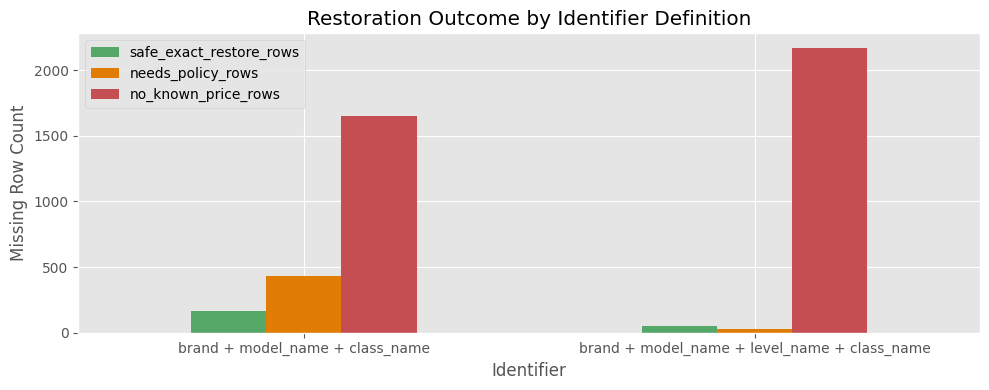

In [9]:
plot_columns = ['safe_exact_restore_rows', 'needs_policy_rows', 'no_known_price_rows']
plot_df = comparison_summary.set_index('key_name')[plot_columns]
ax = plot_df.plot(kind='bar', figsize=(10, 4), color=['#55A868', '#E17C05', '#C44E52'])
ax.set_title('Restoration Outcome by Identifier Definition')
ax.set_xlabel('Identifier')
ax.set_ylabel('Missing Row Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Compact Price Table Proposal

Use `brand + model_name + class_name` as the primary compaction key.
- one known price only: keep that exact price
- multiple known prices: compact to the mean price
- no known price: unresolved


In [10]:
bmc_price_table = bmc_detail[
    [
        'brand',
        'model_name',
        'class_name',
        'rows',
        'missing_rows',
        'known_rows',
        'unique_price_count',
        'min_price',
        'mean_price',
        'median_price',
        'max_price',
        'compaction_method',
        'proposed_compaction_price',
        'restoration_case',
    ]
].sort_values(['restoration_case', 'brand', 'model_name', 'class_name']).reset_index(drop=True)

bmc_price_table.head(30)


,brand,model_name,class_name,rows,missing_rows,known_rows,unique_price_count,min_price,mean_price,median_price,max_price,compaction_method,proposed_compaction_price,restoration_case
0,chevrolet,뉴 볼트 EV,프리미어,1,0,1,1,41300000.0,41300000.0,41300000.0,41300000.0,already_single_price,41300000.0,already_consistent
1,chevrolet,더 넥스트 스파크,LS,1,0,1,1,10360000.0,10360000.0,10360000.0,10360000.0,already_single_price,10360000.0,already_consistent
2,chevrolet,더 넥스트 스파크,LS 베이직,2,0,2,1,9990000.0,9990000.0,9990000.0,9990000.0,already_single_price,9990000.0,already_consistent
3,chevrolet,더 넥스트 스파크,LT,1,0,1,1,11340000.0,11340000.0,11340000.0,11340000.0,already_single_price,11340000.0,already_consistent
4,chevrolet,더 넥스트 스파크,LT 플러스,3,0,3,1,10360000.0,10360000.0,10360000.0,10360000.0,already_single_price,10360000.0,already_consistent
5,chevrolet,더 넥스트 스파크,스페셜 에디션 퍼펙트 블랙,2,0,2,1,15090000.0,15090000.0,15090000.0,15090000.0,already_single_price,15090000.0,already_consistent
6,chevrolet,더 뉴 말리부,LS,1,0,1,1,23450000.0,23450000.0,23450000.0,23450000.0,already_single_price,23450000.0,already_consistent
7,chevrolet,더 뉴 말리부,LS 디럭스,1,0,1,1,24610000.0,24610000.0,24610000.0,24610000.0,already_single_price,24610000.0,already_consistent
8,chevrolet,더 뉴 말리부,LT 스페셜,1,0,1,1,30220000.0,30220000.0,30220000.0,30220000.0,already_single_price,30220000.0,already_consistent
9,chevrolet,더 뉴 말리부,LT 프리미엄,1,0,1,1,31950000.0,31950000.0,31950000.0,31950000.0,already_single_price,31950000.0,already_consistent


In [11]:
bmc_price_table.loc[
    bmc_price_table['restoration_case'] == 'needs_policy_multiple_prices',
    [
        'brand',
        'model_name',
        'class_name',
        'rows',
        'missing_rows',
        'known_rows',
        'unique_price_count',
        'min_price',
        'mean_price',
        'median_price',
        'max_price',
        'proposed_compaction_price',
    ]
].sort_values(['missing_rows', 'unique_price_count', 'rows'], ascending=[False, False, False]).head(30)


,brand,model_name,class_name,rows,missing_rows,known_rows,unique_price_count,min_price,mean_price,median_price,max_price,proposed_compaction_price
1616,hyundai,더 뉴 스타리아,모던,13,9,4,4,34120000.0,3.837000e+07,35745000.0,47870000.0,38370000.0
1617,hyundai,더 뉴 스타리아,스마트,13,9,4,4,32590000.0,3.720250e+07,34175000.0,47870000.0,37202500.0
1674,hyundai,팰리세이드,프레스티지,11,9,2,2,40300000.0,4.103500e+07,41035000.0,41770000.0,41035000.0
1638,hyundai,스타리아,스마트,14,8,6,6,29320000.0,3.518000e+07,36515000.0,38760000.0,35180000.0
1637,hyundai,스타리아,모던,17,7,10,8,30540000.0,3.492500e+07,34660000.0,39990000.0,34925000.0
1799,kia,카니발 4세대,시그니처,11,7,4,4,42360000.0,5.916500e+07,53735000.0,86830000.0,59165000.0
1604,hyundai,그랜드스타렉스,CVX 럭셔리,10,7,3,3,19200000.0,2.058000e+07,20990000.0,21550000.0,20580000.0
1606,hyundai,그랜드스타렉스,CVX 프리미엄,10,7,3,3,19630000.0,2.135333e+07,21880000.0,22550000.0,21353333.333333
1603,hyundai,그랜드스타렉스,CVX 디럭스,8,6,2,2,19390000.0,1.961000e+07,19610000.0,19830000.0,19610000.0
1615,hyundai,더 뉴 스타리아,-,7,5,2,2,47060000.0,4.746500e+07,47465000.0,47870000.0,47465000.0


## BMC Row Distribution


In [12]:
bmc_row_distribution = (
    bmc_price_table['rows']
    .value_counts()
    .sort_index()
    .rename_axis('rows_per_identifier')
    .reset_index(name='identifier_count')
)

bmc_row_distribution


,rows_per_identifier,identifier_count
0,1,929
1,2,670
2,3,323
3,4,262
4,5,93
5,6,131
6,7,44
7,8,70
8,9,33
9,10,24


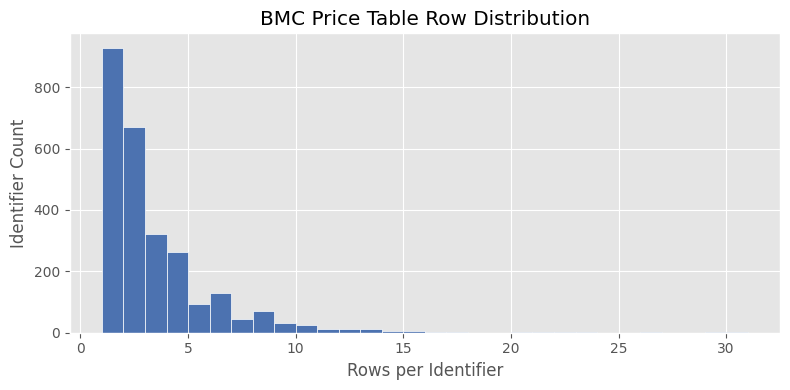

In [13]:
ax = bmc_price_table['rows'].plot(
    kind='hist',
    bins=30,
    figsize=(8, 4),
    color='#4C72B0',
    edgecolor='white',
)
ax.set_title('BMC Price Table Row Distribution')
ax.set_xlabel('Rows per Identifier')
ax.set_ylabel('Identifier Count')
plt.tight_layout()
plt.show()


## No Known Price Groups

These identifiers have no observed launch price at all under the selected key definition.


In [14]:
no_known_price_summary = pd.DataFrame([
    {
        'key_name': 'brand + model_name + class_name',
        'unique_identifiers': int((bmc_detail['restoration_case'] == 'no_known_price').sum()),
        'missing_rows': int(bmc_detail.loc[bmc_detail['restoration_case'] == 'no_known_price', 'missing_rows'].sum()),
    },
    {
        'key_name': 'brand + model_name + level_name + class_name',
        'unique_identifiers': int((bmlc_detail['restoration_case'] == 'no_known_price').sum()),
        'missing_rows': int(bmlc_detail.loc[bmlc_detail['restoration_case'] == 'no_known_price', 'missing_rows'].sum()),
    },
])

no_known_price_summary


,key_name,unique_identifiers,missing_rows
0,brand + model_name + class_name,709,1649
1,brand + model_name + level_name + class_name,2138,2174


In [15]:
no_known_price_by_brand = (
    bmc_detail.loc[bmc_detail['restoration_case'] == 'no_known_price']
    .groupby('brand', dropna=False)
    .agg(
        unique_identifiers=('model_name', 'size'),
        missing_rows=('missing_rows', 'sum'),
    )
    .sort_values(['missing_rows', 'unique_identifiers'], ascending=[False, False])
    .reset_index()
)

no_known_price_by_brand


,brand,unique_identifiers,missing_rows
0,hyundai,390,940
1,kia,171,461
2,kgm,93,176
3,renault,43,56
4,chevrolet,12,16


In [16]:
bmc_detail.loc[
    bmc_detail['restoration_case'] == 'no_known_price',
    ['brand', 'model_name', 'class_name', 'rows', 'missing_rows', 'known_rows']
].sort_values(['missing_rows', 'rows'], ascending=[False, False]).head(500)


,brand,model_name,class_name,rows,missing_rows,known_rows
1201,hyundai,파비스,-,31,31,0
2085,kia,봉고3,-,29,29,0
1229,hyundai,포터2,-,22,22,0
318,hyundai,e마이티,-,21,21,0
1736,kia,뉴 그랜버드,47인승 자가용,15,15,0
...,...,...,...,...,...,...
1019,hyundai,엑시언트,6X4 하이루프캡 520 트랙터,1,1,0
1020,hyundai,엑시언트,6X4 하이루프캡 540 트랙터,1,1,0
1021,hyundai,엑시언트,극초장축,1,1,0
1026,hyundai,엑시언트,특장축,1,1,0
